Number of samples: 569
Number of features: 30
Classes: [0 1]
=== Logistic Regression ===
Accuracy: 0.9736842105263158
Confusion Matrix:
 [[41  2]
 [ 1 70]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

=== SVM (Linear Kernel) ===
Accuracy: 0.956140350877193
Confusion Matrix:
 [[41  2]
 [ 3 68]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



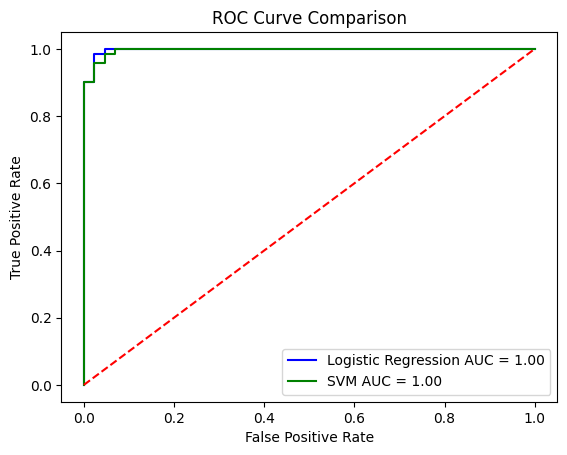


=== Comparison Table ===
                 Model  Accuracy   ROC AUC  Precision (Class 1)  \
0  Logistic Regression  0.973684  0.997380             0.972222   
1  SVM (Linear Kernel)  0.956140  0.996397             0.971429   

   Recall (Class 1)  F1-score (Class 1)  
0          0.985915            0.979021  
1          0.957746            0.964539  


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

# ==========================
# 1. Load Dataset
# ==========================
data = load_breast_cancer()
X = data.data
y = data.target

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Classes:", np.unique(y))

# ==========================
# 2. Train/Test split
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================
# 3. Data Preprocessing (Scaling)
# ==========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================
# 4a. Logistic Regression
# ==========================
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

accuracy_log = accuracy_score(y_test, y_pred_log)
cm_log = confusion_matrix(y_test, y_pred_log)
report_log = classification_report(y_test, y_pred_log, output_dict=True)

# ==========================
# 4b. SVM (Linear Kernel)
# ==========================
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:,1]

accuracy_svm = accuracy_score(y_test, y_pred_svm)
cm_svm = confusion_matrix(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm, output_dict=True)

# ==========================
# 5. Print Metrics
# ==========================
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_log)
print("Confusion Matrix:\n", cm_log)
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

print("=== SVM (Linear Kernel) ===")
print("Accuracy:", accuracy_svm)
print("Confusion Matrix:\n", cm_svm)
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

# ==========================
# 6. ROC Curve Comparison
# ==========================
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
roc_auc_log = auc(fpr_log, tpr_log)

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure()
plt.plot(fpr_log, tpr_log, color='blue', label=f'Logistic Regression AUC = {roc_auc_log:.2f}')
plt.plot(fpr_svm, tpr_svm, color='green', label=f'SVM AUC = {roc_auc_svm:.2f}')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ==========================
# 7. Comparison Table
# ==========================
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM (Linear Kernel)'],
    'Accuracy': [accuracy_log, accuracy_svm],
    'ROC AUC': [roc_auc_log, roc_auc_svm],
    'Precision (Class 1)': [report_log['1']['precision'], report_svm['1']['precision']],
    'Recall (Class 1)': [report_log['1']['recall'], report_svm['1']['recall']],
    'F1-score (Class 1)': [report_log['1']['f1-score'], report_svm['1']['f1-score']]
})

print("\n=== Comparison Table ===")
print(comparison_df)

In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load the dataset
data = load_breast_cancer()

# Create a DataFrame with feature names
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add the target column (0 = malignant, 1 = benign)
df['target'] = data.target

# Optional: map numeric labels to class names
df['target_name'] = df['target'].map({0: 'malignant', 1: 'benign'})

# Show first 5 rows
print(df.head())

# Save to CSV for teaching or sharing
df.to_csv("breast_cancer_dataset.csv", index=False)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst perimeter  worst area  worst smoothness  \
0          